# 1. Data: sources, quality and long-history proxies

**Question:** where do the prices come from, and can they be trusted?

| Source | Content | Used for |
|---|---|---|
| Yahoo Finance | Daily prices of Xetra-listed UCITS ETFs and stocks, adjusted for splits and distributions | Investable portfolios (2009 onwards) |
| FRED | USD/EUR exchange rate, German 3-month rate, euro-area HICP | Currency conversion, cash, inflation |
| Deutsche Bundesbank | Daily 10-year German government yield | Synthetic Bund returns |
| Kenneth R. French Data Library | Developed and European factor returns | Equity proxy, factor models |

All downloads are cached locally in `data/` (Parquet), so the analysis is reproducible offline.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from investor_toolkit import data, proxies, universe
from investor_toolkit.returns import annualized_return, monthly_returns

## Investable universe and data quality

In [2]:
pd.DataFrame([a.__dict__ for a in universe.ASSETS.values()]).set_index("ticker")

,name,asset_class
ticker,,
EUNL.DE,iShares Core MSCI World UCITS ETF (Acc),equity
XGLE.DE,Xtrackers II Eurozone Government Bond UCITS ET...,government_bond
IBCI.DE,iShares Euro Inflation Linked Govt Bond UCITS ...,inflation_linked
4GLD.DE,Xetra-Gold,gold
SAP.DE,SAP SE,single_stock
SIE.DE,Siemens AG,single_stock
ALV.DE,Allianz SE,single_stock
BAYN.DE,Bayer AG,single_stock
DBK.DE,Deutsche Bank AG,single_stock


In [3]:
prices = data.load_prices(list(universe.ASSETS))
data.quality_report(prices)

,first,last,n_obs,missing_pct,max_abs_return,n_jumps,longest_stale_run
EUNL.DE,2009-09-25,2026-10-06,4323,0.069,0.096,0,17
XGLE.DE,2008-01-02,2026-10-06,4764,0.063,0.044,0,3
IBCI.DE,2009-01-14,2026-10-06,4500,0.111,0.058,0,3
4GLD.DE,2009-11-13,2026-10-06,4286,0.117,0.082,0,3
SAP.DE,1998-04-09,2026-10-06,7291,0.000,0.243,11,6
SIE.DE,1996-11-08,2026-10-06,7660,0.000,0.241,4,3
ALV.DE,1996-12-16,2026-10-06,7634,0.000,0.262,4,6
BAYN.DE,1996-12-16,2026-10-06,7634,0.000,0.391,4,24
DBK.DE,1996-11-18,2026-10-06,7654,0.000,0.237,9,6


`missing_pct` counts days without a price inside each series' own date range (exchange holidays
that differ between data feeds). `n_jumps` counts daily moves larger than 15%; for single stocks
these are genuine news events, not data errors. `longest_stale_run` flags runs of unchanged prices,
typical of thinly traded days right after an ETF's launch.

Short gaps are forward-filled (at most five days) and returns are computed month end to month end.
The common sample in which all assets have a return:

In [4]:
returns = universe.load_asset_returns()
print(f"{returns.index[0]:%Y-%m} to {returns.index[-1]:%Y-%m}: {len(returns)} months")

2009-12 to 2026-09: 202 months


## Extending the history to 1999

European UCITS ETFs only exist since about 2009, a period dominated by a long equity bull market.
To include the 2000-2002 and 2008 bear markets, the following monthly EUR series are built from
official sources:

* **World equity:** Fama-French developed-market return (USD, dividends reinvested) converted to EUR.
* **10-year Bund:** a constant-maturity par bond priced from month-end yields. Each month a bond with
  coupon $c = y_{t-1}$ is bought at par and revalued one month later at the new yield $y_t$:

$$R_t = c\,a(y_t, M - \tfrac{1}{12}) + (1 + y_t)^{-(M - 1/12)} - 1 + \frac{c}{12},
\qquad a(y, T) = \frac{1 - (1+y)^{-T}}{y}$$

  For small yield changes this reduces to carry minus duration times the yield change,
  $R_t \approx y_{t-1}/12 - D_\text{mod}\,\Delta y$.
* **Cash:** German 3-month interbank rate. **Inflation:** euro-area HICP.

In [5]:
long = proxies.long_history()
print(f"{long.index[0]:%Y-%m} to {long.index[-1]:%Y-%m}: {len(long)} months")
long.describe().T[["mean", "std", "min", "max"]]

1999-02 to 2026-08: 331 months


,mean,std,min,max
world_equity,0.007,0.041,-1.377e-01,0.116
bund_10y,0.002,0.018,-5.500e-02,0.060
cash,0.001,0.001,-4.850e-04,0.004
inflation,0.002,0.005,-1.548e-02,0.024


## Validating the proxies against real ETFs

Over the period where both exist, each proxy should move with the corresponding investable ETF.
For bonds, the ETF-on-proxy beta should scale with the ETF's interest-rate duration relative to the
10-year proxy.

In [6]:
etf = monthly_returns(
    data.clean_prices(data.load_prices(["EUNL.DE", "X03G.DE", "EXHA.DE", "EXX6.DE", "XGLE.DE"]))
)
pairs = [
    ("world_equity", "EUNL.DE", "MSCI World ETF"),
    ("bund_10y", "EXHA.DE", "German govt, all maturities"),
    ("bund_10y", "X03G.DE", "German govt, broad"),
    ("bund_10y", "EXX6.DE", "German govt, 10.5+ years"),
    ("bund_10y", "XGLE.DE", "Euro-area govt (incl. periphery)"),
]
rows = []
for proxy, ticker, label in pairs:
    both = pd.concat([long[proxy], etf[ticker]], axis=1, join="inner").dropna()
    x, y = both[proxy], both[ticker]
    rows.append(
        {
            "proxy": proxy,
            "etf": ticker,
            "description": label,
            "months": len(both),
            "correlation": x.corr(y),
            "beta_etf_on_proxy": np.cov(y, x)[0, 1] / x.var(),
            "tracking_error": (x - y).std() * np.sqrt(12),
            "cagr_proxy": annualized_return(x, 12),
            "cagr_etf": annualized_return(y, 12),
        }
    )
validation = pd.DataFrame(rows).set_index(["proxy", "etf"])
validation

description  months  correlation  beta_etf_on_proxy  tracking_error  \
proxy        etf                                                                                                 
world_equity EUNL.DE                    MSCI World ETF     203        0.978              0.974           0.026   
bund_10y     EXHA.DE       German govt, all maturities     223        0.814              0.460           0.042   
             X03G.DE                German govt, broad     180        0.951              0.735           0.023   
             EXX6.DE          German govt, 10.5+ years     223        0.926              1.599           0.058   
             XGLE.DE  Euro-area govt (incl. periphery)     223        0.872              0.673           0.033   

                      cagr_proxy  cagr_etf  
proxy        etf                            
world_equity EUNL.DE       0.126     0.125  
bund_10y     EXHA.DE       0.018     0.004  
             X03G.DE       0.004     0.001  
             EXX6.DE       0.018     0.011  
             XGLE.DE       0.018     0.021

The equity proxy reproduces the MSCI World ETF closely in both co-movement and long-run return.
The bond proxy is highly correlated with German government bond ETFs of comparable duration, and
the betas order exactly as the bonds' maturities do: the all-maturity index moves less than the
10-year proxy, the 10.5+ year index more. The all-maturity index also correlates less, because its
short bonds respond to the front end of the yield curve rather than the 10-year point. The
euro-area ETF correlates less than German ETFs of similar duration because it also carries
Italian and Spanish credit spreads, which a Bund proxy cannot capture.

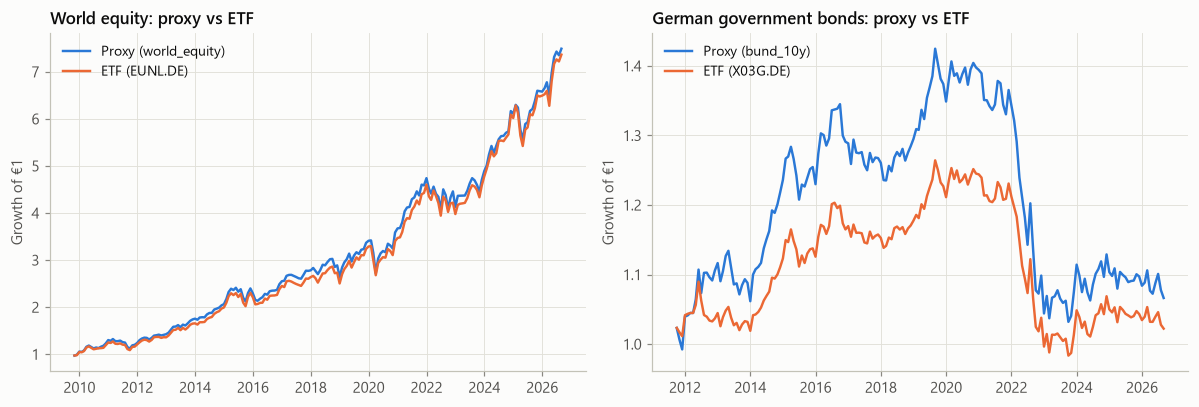

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (proxy, ticker, title) in zip(
    axes,
    [
        ("world_equity", "EUNL.DE", "World equity: proxy vs ETF"),
        ("bund_10y", "X03G.DE", "German government bonds: proxy vs ETF"),
    ],
    strict=True,
):
    both = pd.concat([long[proxy], etf[ticker]], axis=1, join="inner").dropna()
    wealth = (1 + both).cumprod()
    wealth.columns = [f"Proxy ({proxy})", f"ETF ({ticker})"]
    ax.plot(wealth.index, wealth.iloc[:, 0], color="#2a78d6", label=wealth.columns[0])
    ax.plot(wealth.index, wealth.iloc[:, 1], color="#eb6834", label=wealth.columns[1])
    ax.set_title(title)
    ax.set_ylabel("Growth of €1")
    ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(f"{FIGURES}/proxy_validation.png")

The bond proxy accumulates a different level than the broad ETF because it has a longer duration
(it gained more when yields fell until 2020 and lost more in 2022). That is a difference in
exposure, not an error: the betas above quantify it.